In [1]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

from datasets.visual_genome import (
    VisualGenomeLoader,
    show_scene,
    Scene,
    SceneObject,
    Relationship,
    BoundingBox
)

import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
loader = VisualGenomeLoader("../datasets/visual_genome")

IMAGE INFORMATION
----------------------------------------------------------------------
Image Index : 0
Image ID    : 1
Resolution  : 800 × 600
Objects     : 23
Relations   : 25

OBJECTS
----------------------------------------------------------------------
[0] clock
Bounding Box : (459.375, 259.375, 79.6875, 339.0625)

[1] street
Bounding Box : (435.15625, 459.375, 718.75, 264.0625)

[2] person
Bounding Box : (264.84375, 380.46875, 72.65625, 266.40625)

[3] car
Bounding Box : (514.0625, 362.5, 74.21875, 98.4375)

[4] bike
Bounding Box : (340.625, 335.15625, 42.1875, 35.15625)


RELATIONSHIPS
----------------------------------------------------------------------
person ---- wearing ----> shoe
sign ---- on ----> building
person ---- has ----> shirt
car ---- has ----> back
person ---- wearing ----> shoe


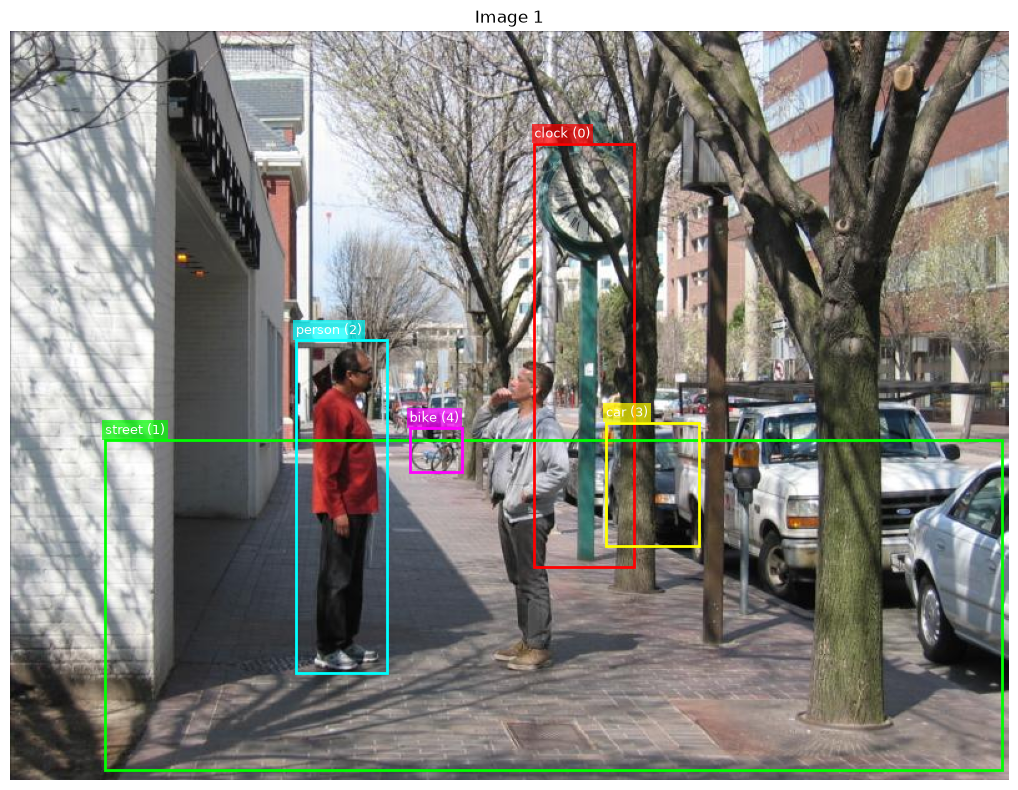

In [3]:
scene = loader.load_scene(0)
show_scene(
    scene,
    num_objects=5,
    num_rels=5
)

In [4]:
print(f"Number of Objects       : {len(scene.objects)}")
print(f"Number of Relationships : {len(scene.relationships)}")

Number of Objects       : 23
Number of Relationships : 25


In [5]:
rel = scene.relationships[0]
print("=" * 60)

print("SUBJECT")

print(rel.subject.label)
print(rel.subject.bbox)

print()

print("OBJECT")

print(rel.object.label)
print(rel.object.bbox)

print()

print("TARGET")

print(rel.predicate)

SUBJECT
person
BoundingBox(cx=264.84375, cy=380.46875, width=72.65625, height=266.40625)

OBJECT
shoe
BoundingBox(cx=412.5, cy=496.875, width=46.09375, height=34.375)

TARGET
wearing


In [6]:
relationship = scene.relationships[0]
subject = relationship.subject

obj = relationship.object

predicate = relationship.predicate
print(subject.label)
print(subject.bbox)

print()

print(obj.label)
print(obj.bbox)

print()

print(predicate)

person
BoundingBox(cx=264.84375, cy=380.46875, width=72.65625, height=266.40625)

shoe
BoundingBox(cx=412.5, cy=496.875, width=46.09375, height=34.375)

wearing


#### GOnna start actually building the dataset for rel model

In [7]:
def bbox_to_xyxy(box: BoundingBox):
    #Converting cx,cy,w,h to x1,y1,x2,y2
    

    x1 = box.cx - box.width / 2
    y1 = box.cy - box.height / 2

    x2 = box.cx + box.width / 2
    y2 = box.cy + box.height / 2

    return x1, y1, x2, y2

In [8]:
bbox_to_xyxy(subject.bbox)

(228.515625, 247.265625, 301.171875, 513.671875)

### GOnna get the two images and unioning them to get a sub image

In [9]:
def get_union_bbox(box1: BoundingBox, box2: BoundingBox, padding: float):

    x1_1, y1_1, x2_1, y2_1 = bbox_to_xyxy(box1)
    x1_2, y1_2, x2_2, y2_2 = bbox_to_xyxy(box2)

    left = min(x1_1, x1_2)
    top = min(y1_1, y1_2)
    right = max(x2_1, x2_2)
    bottom = max(y2_1, y2_2)
    
    pad_x = (right - left) * padding
    pad_y = (bottom - top) * padding

    left -= pad_x
    right += pad_x
    top -= pad_y
    bottom += pad_y
    
    
    width = right - left
    height = bottom - top

    cx = left + width / 2
    cy = top + height / 2

    return BoundingBox(
        cx=cx,
        cy=cy,
        width=width,
        height=height
    )

In [10]:
union_box = get_union_bbox(subject.bbox, obj.bbox,padding=0.05)

print(union_box)

BoundingBox(cx=332.03125, cy=380.6640625, width=227.734375, height=293.4765625)


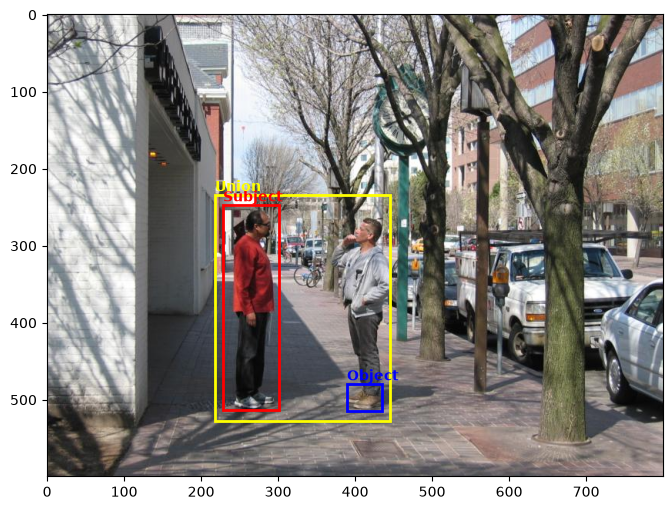

In [11]:
fig, ax = plt.subplots(figsize=(8,6))

ax.imshow(scene.image)

colors = [
    ("red", subject.bbox, "Subject"),
    ("blue", obj.bbox, "Object"),
    ("yellow", union_box, "Union")
]

for color, box, name in colors:

    x = box.cx - box.width/2
    y = box.cy - box.height/2

    rect = patches.Rectangle(
        (x, y),
        box.width,
        box.height,
        linewidth=2,
        edgecolor=color,
        facecolor="none"
    )

    ax.add_patch(rect)

    ax.text(
        x,
        y-5,
        name,
        color=color,
        fontsize=10,
        weight="bold"
    )

plt.show()

In [12]:
def crop_union_region(image, union_box: BoundingBox):

    x1, y1, x2, y2 = bbox_to_xyxy(union_box)

    w,h = image.size

    x1 = max(0, int(round(x1)))
    y1 = max(0, int(round(y1)))

    x2 = min(w, int(round(x2)))
    y2 = min(h, int(round(y2)))

    return image.crop((x1, y1, x2, y2))

(228, 293)


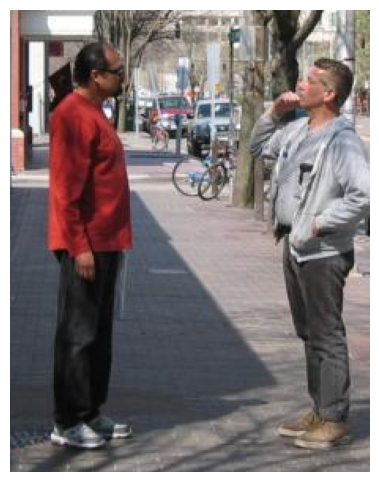

In [13]:
crop = crop_union_region(scene.image, union_box)

print(crop.size)

plt.figure(figsize=(6, 6))
plt.imshow(crop)
plt.axis("off")
plt.show()

In [14]:
def bbox_relative_to_crop(
    bbox: BoundingBox,
    crop_box: BoundingBox
):
    """
    Convert a bounding box from image coordinates
    to coordinates relative to the union crop.
    """

    crop_x1, crop_y1, _, _ = bbox_to_xyxy(crop_box)

    x1, y1, x2, y2 = bbox_to_xyxy(bbox)

    x1 -= crop_x1
    y1 -= crop_y1

    x2 -= crop_x1
    y2 -= crop_y1

    width = x2 - x1
    height = y2 - y1

    cx = x1 + width / 2
    cy = y1 + height / 2

    return BoundingBox(
        cx=cx,
        cy=cy,
        width=width,
        height=height
    )

In [15]:
subject_crop_box = bbox_relative_to_crop(
    subject.bbox,
    union_box
)

object_crop_box = bbox_relative_to_crop(
    obj.bbox,
    union_box
)

print(subject_crop_box)
print(object_crop_box)

BoundingBox(cx=46.6796875, cy=146.54296875, width=72.65625, height=266.40625)
BoundingBox(cx=194.3359375, cy=262.94921875, width=46.09375, height=34.375)


In [16]:
def normalize_bbox(
    bbox: BoundingBox,
    crop_box: BoundingBox
):

    return BoundingBox(
        cx=bbox.cx / crop_box.width,
        cy=bbox.cy / crop_box.height,
        width=bbox.width / crop_box.width,
        height=bbox.height / crop_box.height
    )

In [17]:
subject_norm = normalize_bbox(
    subject_crop_box,
    union_box
)

object_norm = normalize_bbox(
    object_crop_box,
    union_box
)

print(subject_norm)
print(object_norm)

BoundingBox(cx=0.20497427101200685, cy=0.49933448688939175, width=0.3190394511149228, height=0.9077598828696926)
BoundingBox(cx=0.8533447684391081, cy=0.895980300811926, width=0.20240137221269297, height=0.1171303074670571)


In [18]:
def create_positive_index(
    image_index: int,
    relationship: Relationship
):

    return {

        "image_index": image_index,

        "subject_box_index": relationship.subject.object_index,

        "object_box_index": relationship.object.object_index,

        "predicate": relationship.predicate
    }

In [19]:
sample = create_positive_index(
    scene.info.image_index,
    relationship
)

sample

{'image_index': 0,
 'subject_box_index': 2,
 'object_box_index': 11,
 'predicate': 'wearing'}

In [20]:
def create_positive_sample(
    scene: Scene,
    relationship: Relationship
):

    subject = relationship.subject
    obj = relationship.object

    union_box = get_union_bbox(
        subject.bbox,
        obj.bbox,
        padding=0.05
    )

    crop = crop_union_region(
        scene.image,
        union_box
    )

    subject_box = bbox_relative_to_crop(
        subject.bbox,
        union_box
    )

    object_box = bbox_relative_to_crop(
        obj.bbox,
        union_box
    )

    subject_box = normalize_bbox(
        subject_box,
        union_box
    )

    object_box = normalize_bbox(
        object_box,
        union_box
    )

    return {

        "image": crop,

        "subject_label": subject.label,
        "object_label": obj.label,

        "subject_bbox": subject_box,
        "object_bbox": object_box,

        "predicate": relationship.predicate
    }

subject_label
person

object_label
shoe

subject_bbox
BoundingBox(cx=0.20497427101200685, cy=0.49933448688939175, width=0.3190394511149228, height=0.9077598828696926)

object_bbox
BoundingBox(cx=0.8533447684391081, cy=0.895980300811926, width=0.20240137221269297, height=0.1171303074670571)

predicate
wearing



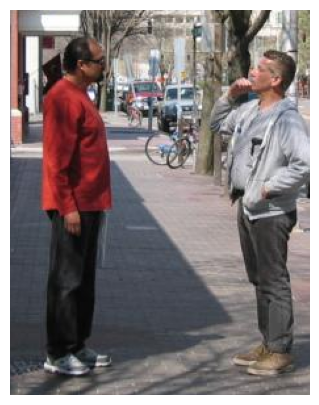

In [21]:
sample = create_positive_sample(
    scene,
    relationship
)
for key, value in sample.items():

    if key == "image":
        continue

    print(f"{key}")
    print(value)
    print()
plt.figure(figsize=(5,5))

plt.imshow(sample["image"])

plt.axis("off")

plt.show()

In [22]:
def generate_positive_samples(scene: Scene):

    samples = []

    for relationship in scene.relationships:

        sample = create_positive_sample(
            scene,
            relationship
        )

        samples.append(sample)

    return samples

In [23]:
positive_samples = generate_positive_samples(scene)

for i, sample in enumerate(positive_samples[:5]):

    print("=" * 60)
    print(f"Sample {i+1}")

    print(f"Subject   : {sample['subject_label']}")
    print(f"Object    : {sample['object_label']}")
    print(f"Predicate : {sample['predicate']}")

Sample 1
Subject   : person
Object    : shoe
Predicate : wearing
Sample 2
Subject   : sign
Object    : building
Predicate : on
Sample 3
Subject   : person
Object    : shirt
Predicate : has
Sample 4
Subject   : car
Object    : back
Predicate : has
Sample 5
Subject   : person
Object    : shoe
Predicate : wearing


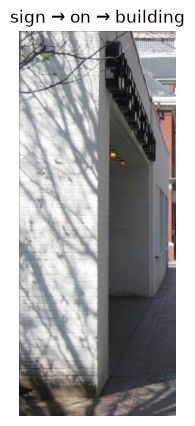

In [24]:
sample = positive_samples[1]

plt.figure(figsize=(5,5))

plt.imshow(sample["image"])

plt.title(
    f"{sample['subject_label']} → {sample['predicate']} → {sample['object_label']}"
)

plt.axis("off")

plt.show()

## Positive Samples Dataset build

In [25]:
def expand_bbox(
    bbox: BoundingBox,
    expansion: float = 0.35
):
    """
    Expand a bounding box by a percentage.
    """

    new_width = bbox.width * (1 + expansion)
    new_height = bbox.height * (1 + expansion)

    return BoundingBox(
        cx=bbox.cx,
        cy=bbox.cy,
        width=new_width,
        height=new_height
    )

In [26]:
expanded = expand_bbox(subject.bbox)

print(subject.bbox)
print(expanded)

BoundingBox(cx=264.84375, cy=380.46875, width=72.65625, height=266.40625)
BoundingBox(cx=264.84375, cy=380.46875, width=98.0859375, height=359.6484375)


In [27]:
def boxes_intersect(
    box1: BoundingBox,
    box2: BoundingBox
):

    x1_1, y1_1, x2_1, y2_1 = bbox_to_xyxy(box1)
    x1_2, y1_2, x2_2, y2_2 = bbox_to_xyxy(box2)

    return not (
        x2_1 < x1_2 or
        x2_2 < x1_1 or
        y2_1 < y1_2 or
        y2_2 < y1_1
    )

In [28]:
boxes_intersect(
    subject.bbox,
    obj.bbox
)

False

In [29]:
def are_candidate_negative(
    subject_box: BoundingBox,
    object_box: BoundingBox,
    expansion: float = 0.2
):
    """
    Two objects are candidate negatives if their
    expanded boxes intersect.
    """

    subject_box = expand_bbox(
        subject_box,
        expansion
    )

    object_box = expand_bbox(
        object_box,
        expansion
    )

    return boxes_intersect(
        subject_box,
        object_box
    )

In [30]:
print(
    are_candidate_negative(
        subject.bbox,
        obj.bbox
    )
)

False


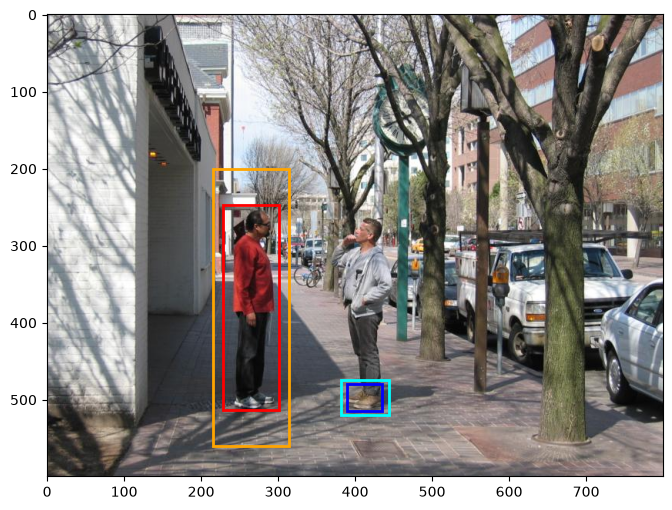

In [31]:
fig, ax = plt.subplots(figsize=(8,6))

ax.imshow(scene.image)

colors = [
    ("red", subject.bbox),
    ("blue", obj.bbox),
    ("orange", expand_bbox(subject.bbox)),
    ("cyan", expand_bbox(obj.bbox))
]

for color, box in colors:

    x = box.cx - box.width/2
    y = box.cy - box.height/2

    rect = patches.Rectangle(
        (x, y),
        box.width,
        box.height,
        linewidth=2,
        edgecolor=color,
        facecolor="none"
    )

    ax.add_patch(rect)

plt.show()

In [32]:
def get_positive_pairs(scene: Scene):

    positive_pairs = set()

    for relationship in scene.relationships:

        positive_pairs.add(
            (
                relationship.subject.object_index,
                relationship.object.object_index
            )
        )

    return positive_pairs

In [33]:
positive_pairs = get_positive_pairs(scene)

print(len(positive_pairs))

print(list(positive_pairs)[:5])

17
[(9, 10), (4, 16), (18, 1), (2, 7), (4, 1)]


In [34]:
def get_candidate_negative_pairs(scene: Scene):

    candidates = []

    positive_pairs = get_positive_pairs(scene)

    objects = scene.objects

    for subject in objects:

        for obj in objects:

            if subject.object_index == obj.object_index:
                continue

            pair = (
                subject.object_index,
                obj.object_index
            )

            if pair in positive_pairs:
                continue

            if not are_candidate_negative(
                subject.bbox,
                obj.bbox
            ):
                continue

            candidates.append(
                (
                    subject,
                    obj
                )
            )

    return candidates

In [35]:
candidate_negatives = get_candidate_negative_pairs(scene)

print(len(candidate_negatives))
for subject, obj in candidate_negatives[:10]:

    print(
        subject.label,
        "---- no_relation ---->",
        obj.label
    )

186
clock ---- no_relation ----> street
clock ---- no_relation ----> car
clock ---- no_relation ----> street
clock ---- no_relation ----> person
clock ---- no_relation ----> jacket
clock ---- no_relation ----> pant
clock ---- no_relation ----> tree
clock ---- no_relation ----> shirt
clock ---- no_relation ----> road
street ---- no_relation ----> clock


In [36]:
import random

def sample_negative_pairs(
    scene: Scene,
    num_samples: int
):

    candidates = get_candidate_negative_pairs(
        scene
    )

    if len(candidates) <= num_samples:
        return candidates

    return random.sample(
        candidates,
        num_samples
    )

In [37]:
negative_pairs = sample_negative_pairs(
    scene,
    len(scene.relationships)
)

print(len(negative_pairs))

25


In [38]:
def create_negative_sample(
    scene: Scene,
    subject: SceneObject,
    obj: SceneObject
):

    union_box = get_union_bbox(
        subject.bbox,
        obj.bbox,
        padding=0.05
    )

    crop = crop_union_region(
        scene.image,
        union_box
    )

    subject_box = normalize_bbox(
        bbox_relative_to_crop(
            subject.bbox,
            union_box
        ),
        union_box
    )

    object_box = normalize_bbox(
        bbox_relative_to_crop(
            obj.bbox,
            union_box
        ),
        union_box
    )

    return {

        "image": crop,

        "subject_label": subject.label,
        "object_label": obj.label,

        "subject_bbox": subject_box,
        "object_bbox": object_box,

        "predicate": "no_relation"
    }

In [39]:
negative_samples = []

for subject, obj in negative_pairs:

    negative_samples.append(
        create_negative_sample(
            scene,
            subject,
            obj
        )
    )

print(len(negative_samples))

25


### Negative Samples Created

In [40]:
def generate_scene_samples(scene: Scene):

    positive = generate_positive_samples(scene)

    negative_pairs = sample_negative_pairs(
        scene,
        len(positive)
    )

    negative = []

    for subject, obj in negative_pairs:

        negative.append(
            create_negative_sample(
                scene,
                subject,
                obj
            )
        )

    return {

        "positive": positive,

        "negative": negative
    }

In [41]:
samples = generate_scene_samples(scene)

print(
    len(samples["positive"])
)

print(
    len(samples["negative"])
)

25
25


Subject : building
Object  : shirt
Target  : no_relation


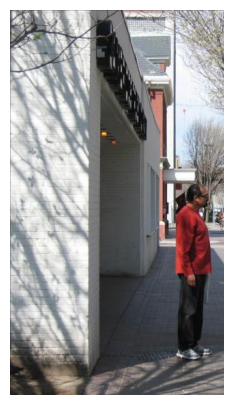

In [42]:
import random

sample = random.choice(
    samples["positive"] +
    samples["negative"]
)

print("Subject :", sample["subject_label"])
print("Object  :", sample["object_label"])
print("Target  :", sample["predicate"])

plt.figure(figsize=(5,5))
plt.imshow(sample["image"])
plt.axis("off")
plt.show()

### Generated pos and negative classes